# 🖼️ Dataset 4: Natural Images - EfficientNetB0 + Grad-CAM
## Kỹ thuật: EfficientNet Transfer Learning + Grad-CAM Explainability

**Pipeline:** Dataset Analysis → Samples → Build EfficientNetB0 → Train → Confusion Matrix → Grad-CAM

---

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import matplotlib.cm as cm_plt
import seaborn as sns
import numpy as np
import cv2
import os
import random

SEED = 42

os.environ['PYTHONHASHSEED'] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# TensorFlow deterministic ops
tf.keras.utils.set_random_seed(SEED)
tf.config.experimental.enable_op_determinism()

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11,
                     'axes.titlesize': 12, 'axes.titleweight': 'bold'})

DATA_DIR = '../data/natural_images/natural_images'
SAVE_DIR = '../results/natural_images'
os.makedirs(SAVE_DIR, exist_ok=True)

IMG_SIZE   = (224, 224)
BATCH_SIZE = 64
EPOCHS     = 20

print(f'TF: {tf.__version__}')
print(f'Random Seed: {SEED}')


I0000 00:00:1780139354.865767 2969160 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780139354.899879 2969160 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780139355.710738 2969160 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TF: 2.21.0
Random Seed: 42


## 📊 1. Dataset Analysis

In [2]:
classes = sorted([d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))])
class_counts = {c: len(os.listdir(os.path.join(DATA_DIR, c))) for c in classes}

print(f'Classes ({len(classes)}): {classes}')
for c, n in class_counts.items():
    print(f'  {c:12s}: {n:,} images')
print(f'  Total      : {sum(class_counts.values()):,}')

Classes (8): ['airplane', 'car', 'cat', 'dog', 'flower', 'fruit', 'motorbike', 'person']
  airplane    : 727 images
  car         : 968 images
  cat         : 885 images
  dog         : 702 images
  flower      : 843 images
  fruit       : 1,000 images
  motorbike   : 788 images
  person      : 986 images
  Total      : 6,899


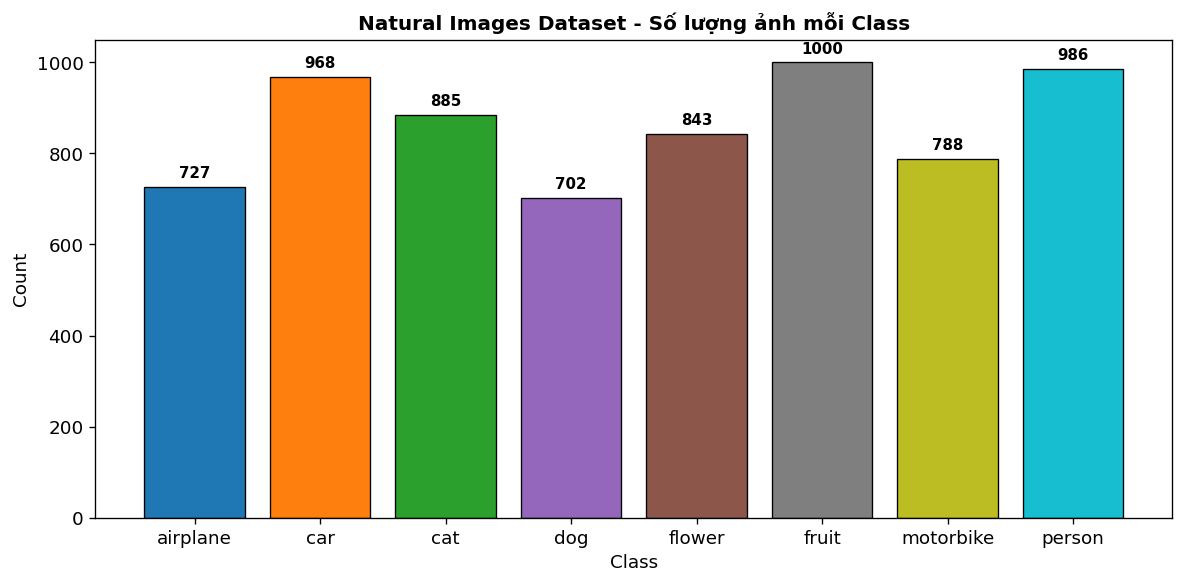

In [3]:
# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))
colors = plt.cm.tab10(np.linspace(0, 1, len(classes)))
bars = ax.bar(class_counts.keys(), class_counts.values(),
              color=colors, edgecolor='black', linewidth=0.8)
ax.set_title('Natural Images Dataset - Số lượng ảnh mỗi Class')
ax.set_ylabel('Count')
ax.set_xlabel('Class')
for bar, val in zip(bars, class_counts.values()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+20,
            f'{val}', ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/01_class_distribution.png', bbox_inches='tight')
plt.show()

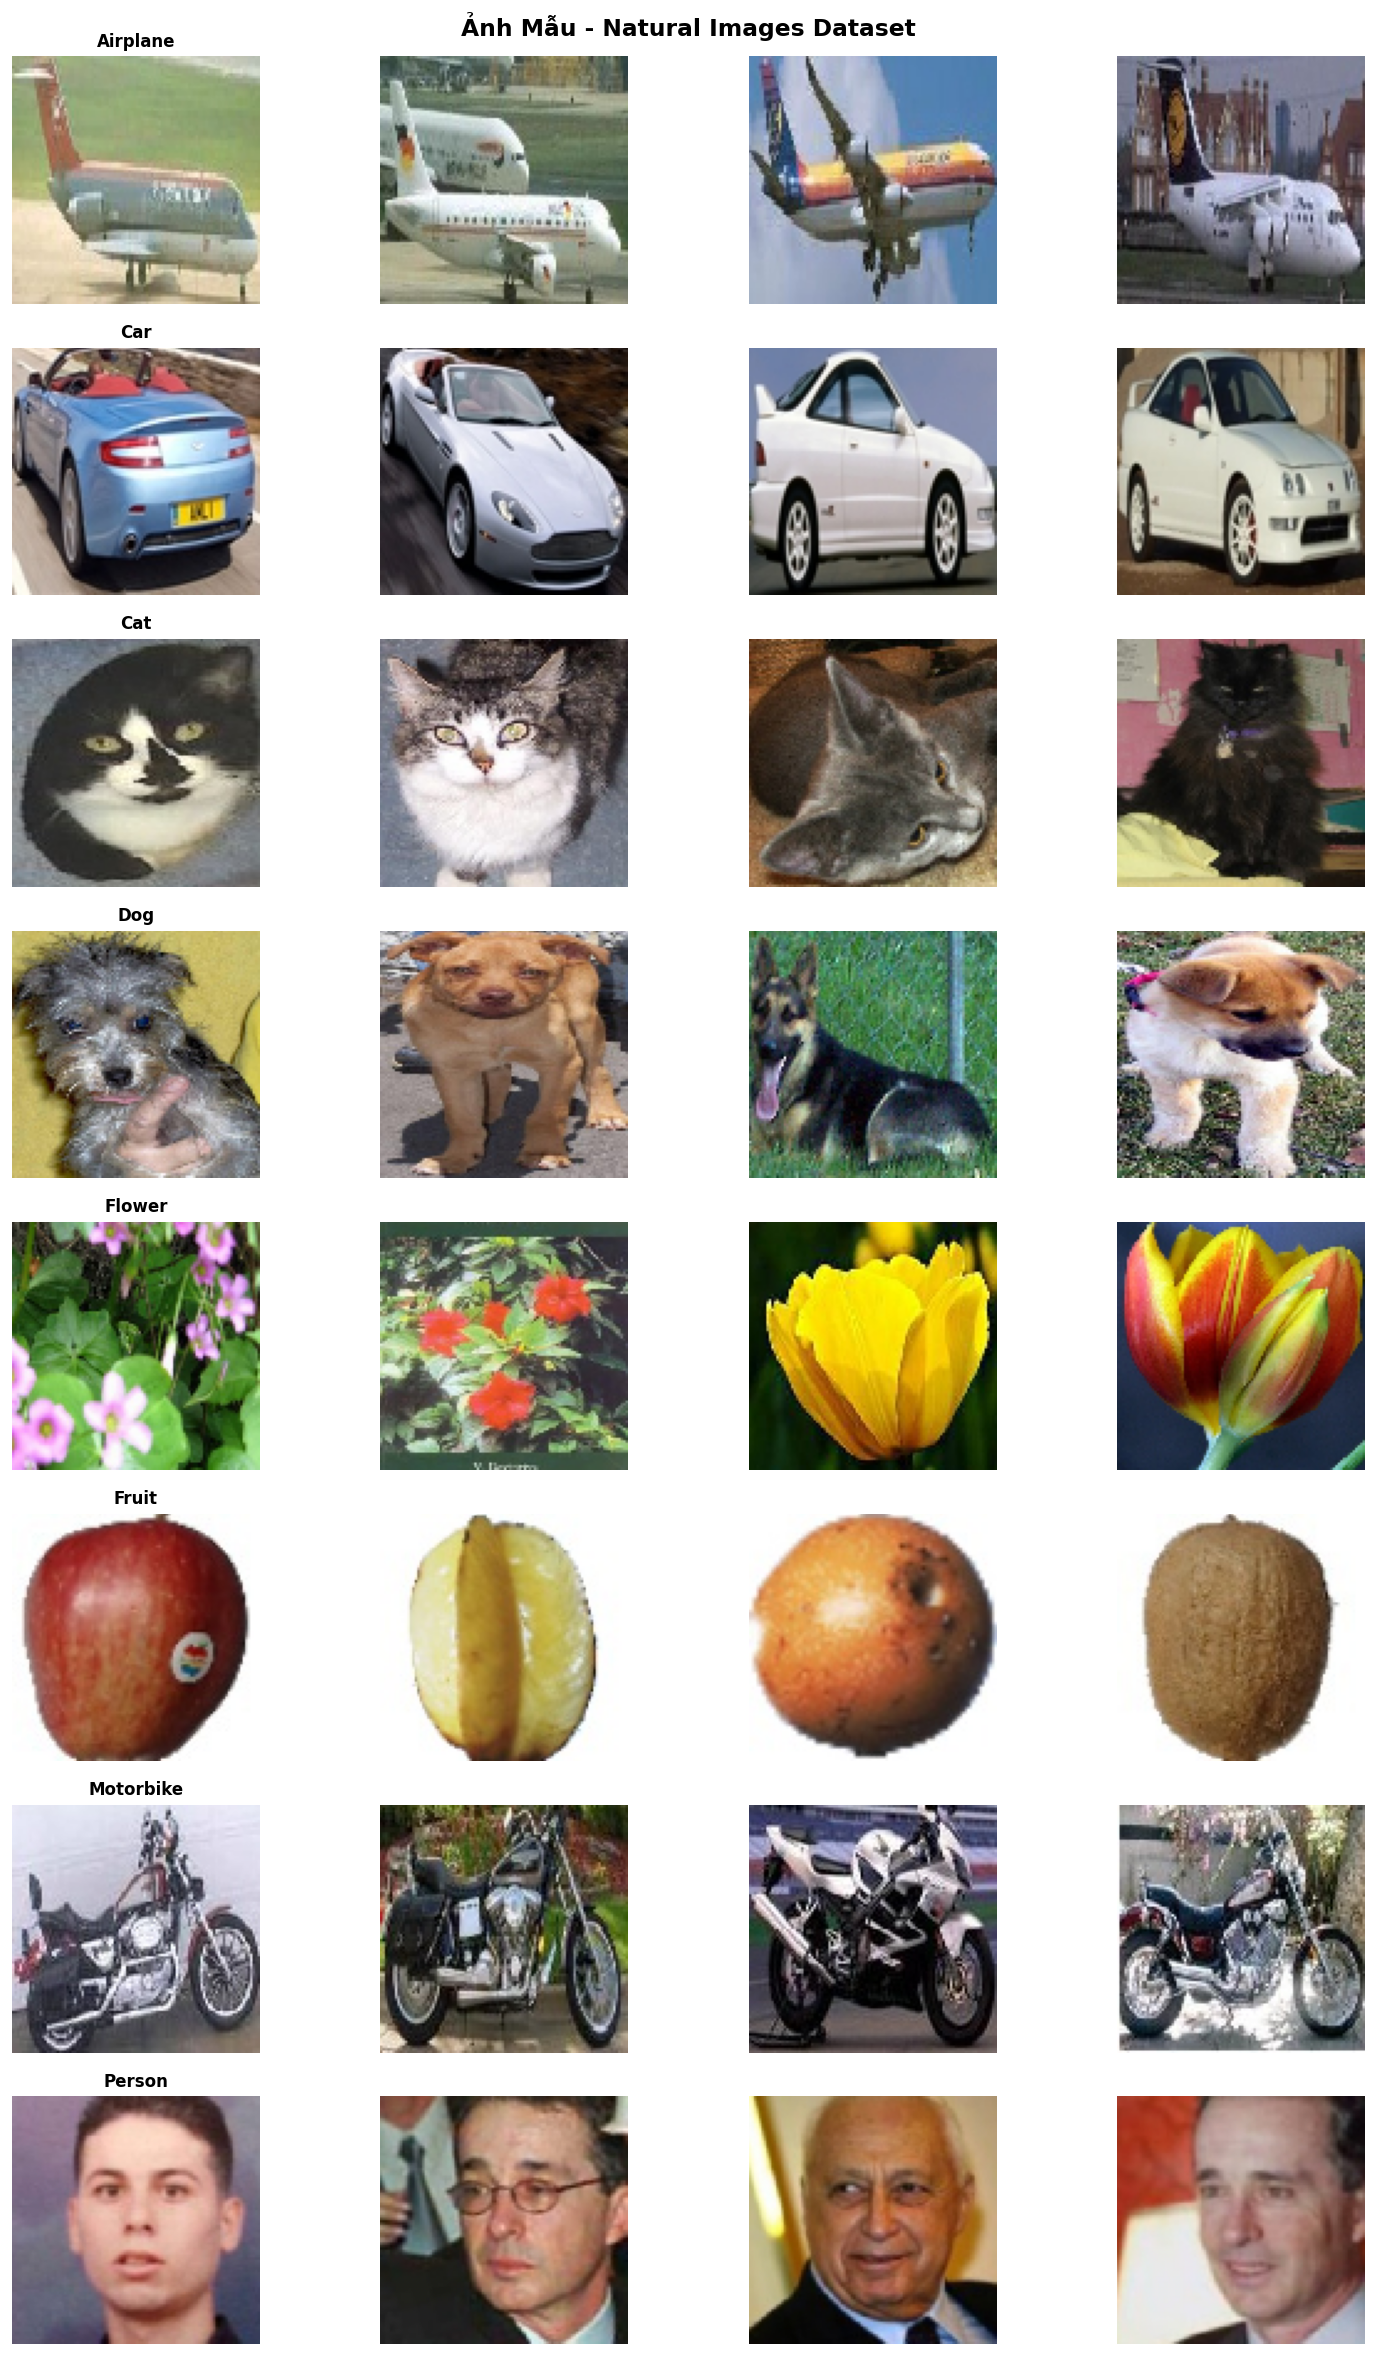

In [4]:
# Sample images grid
cols = 4
rows = len(classes)
fig, axes = plt.subplots(rows, cols, figsize=(13, rows*2.5))

for r, cls in enumerate(classes):
    cls_dir = os.path.join(DATA_DIR, cls)
    img_files = [f for f in os.listdir(cls_dir) if f.lower().endswith(('.jpg','.jpeg','.png'))][:cols]
    for c, fname in enumerate(img_files):
        img = load_img(os.path.join(cls_dir, fname), target_size=(100, 100))
        axes[r, c].imshow(img)
        axes[r, c].axis('off')
        if c == 0:
            axes[r, c].set_title(cls.capitalize(), fontweight='bold', fontsize=10)

plt.suptitle('Ảnh Mẫu - Natural Images Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/02_sample_images.png', bbox_inches='tight')
plt.show()

## 🏗️ 2. Build EfficientNetB0

In [5]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.15,
    shear_range=0.1,
    fill_mode='nearest',
    validation_split=0.2
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

train_gen = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=SEED,
    shuffle=True
)

val_gen = val_datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=SEED,
    shuffle=False
)

classes = list(train_gen.class_indices.keys())
print(f'Classes: {classes}')
print(f'Train samples: {train_gen.samples}, Val samples: {val_gen.samples}')


Found 5522 images belonging to 8 classes.
Found 1377 images belonging to 8 classes.
Classes: ['airplane', 'car', 'cat', 'dog', 'flower', 'fruit', 'motorbike', 'person']
Train samples: 5522, Val samples: 1377


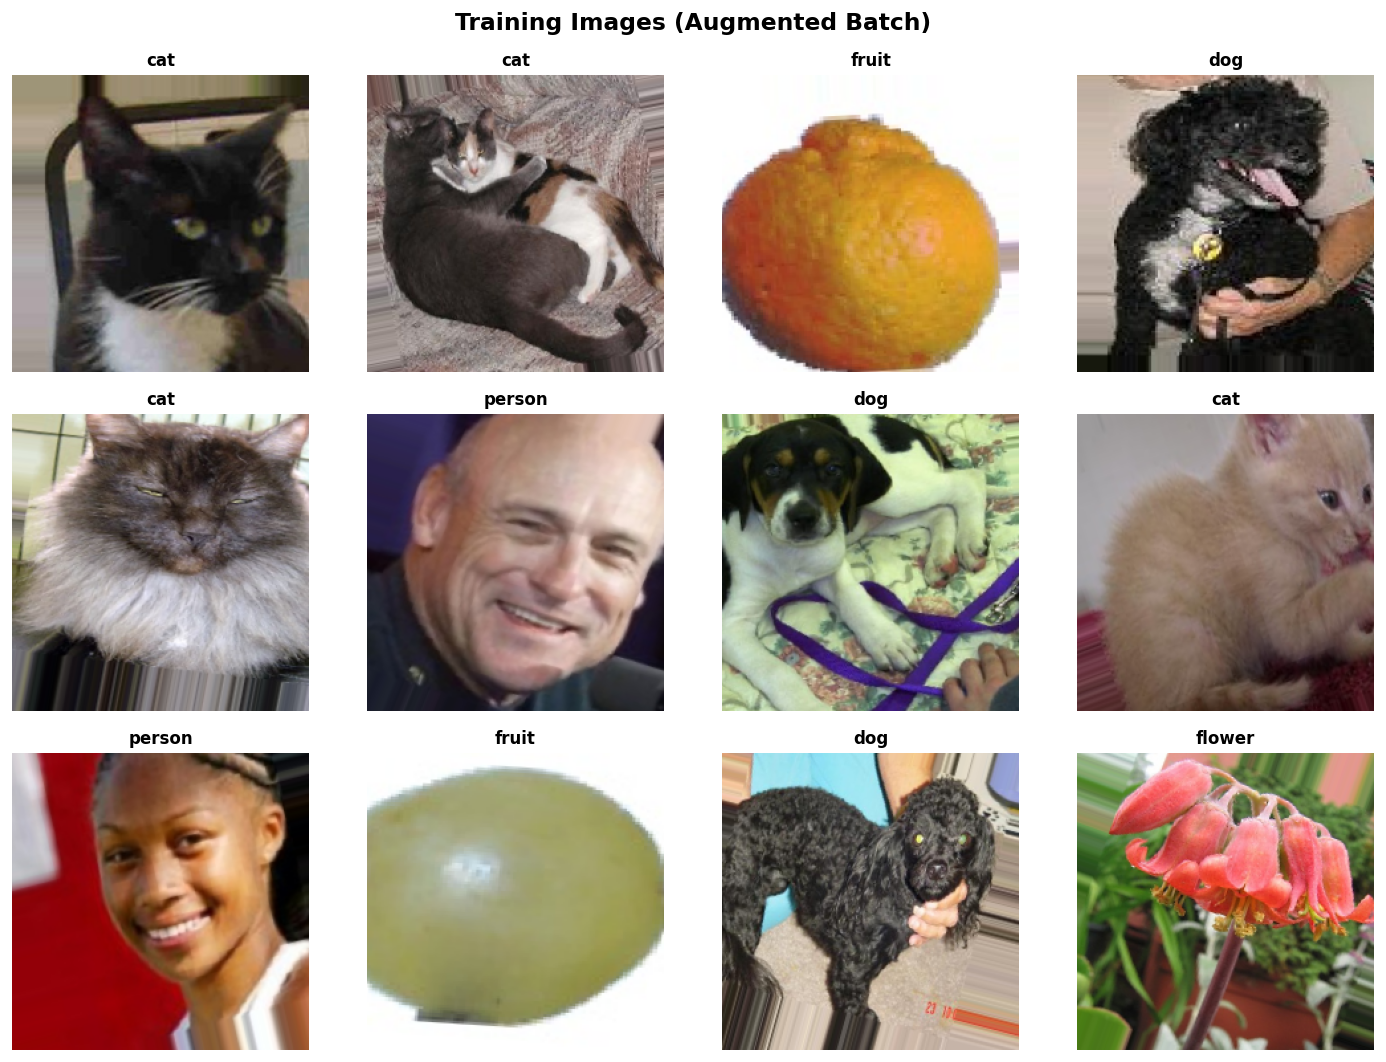

In [6]:
# Visualize training images
x_batch, y_batch = next(train_gen)

fig, axes = plt.subplots(3, 4, figsize=(12, 9))
axes = axes.flatten()

for i, ax in enumerate(axes):
    img = x_batch[i]
    label = classes[np.argmax(y_batch[i])]

    ax.imshow((img / 255.0).clip(0, 1))
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.axis('off')

plt.suptitle('Training Images (Augmented Batch)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/03_train_batch_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

In [7]:
# Build EfficientNetB0 Transfer Learning model

base = EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=(*IMG_SIZE, 3)
)
base.trainable = False  # Freeze base, train head

inputs  = layers.Input(shape=(*IMG_SIZE, 3))
x       = base(inputs, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dense(256, activation='relu')(x)
x       = layers.Dropout(0.4)(x)
outputs = layers.Dense(len(classes), activation='softmax')(x)

model = models.Model(inputs, outputs)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()
print(f'Total params: {model.count_params():,}')


I0000 00:00:1780139368.550943 2969160 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 916 MB memory:  -> device: 0, name: NVIDIA RTX 5880 Ada Generation, pci bus id: 0000:01:00.0, compute capability: 8.9
I0000 00:00:1780139368.552849 2969160 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 46288 MB memory:  -> device: 1, name: NVIDIA RTX 5880 Ada Generation, pci bus id: 0000:41:00.0, compute capability: 8.9
I0000 00:00:1780139368.555419 2969160 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 698 MB memory:  -> device: 2, name: NVIDIA RTX 5880 Ada Generation, pci bus id: 0000:83:00.0, compute capability: 8.9


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         2,056 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,384,683 (16.73 MB)

 Trainable params: 332,552 (1.27 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

Total params: 4,384,683


## 🚀 3. Training

In [8]:
# ── Phase 1: Train head (base frozen) ──────────────────────
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        patience=5, restore_best_weights=True, monitor='val_accuracy'
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        factor=0.5, patience=3, min_lr=1e-7, verbose=1
    )
]

history = model.fit(
    train_gen, epochs=EPOCHS, validation_data=val_gen,
    callbacks=callbacks, verbose=1
)

# ── Phase 2: Fine-tune – unfreeze top layers của base ─────
print("\nFine-tuning phase: unfreeze top 30 layers of EfficientNetB0...")
base.trainable = True
# Freeze tất cả trừ 30 layer cuối
for layer in base.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  # lr nhỏ hơn
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_ft = model.fit(
    train_gen, epochs=10, validation_data=val_gen,
    callbacks=callbacks, verbose=1
)

for key in history.history:
    history.history[key] += history_ft.history.get(key, [])


Epoch 1/20


I0000 00:00:1780139370.690307 2969160 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1780139375.439218 2971329 cuda_dnn.cc:461] Loaded cuDNN version 92101


87/87 ━━━━━━━━━━━━━━━━━━━━ 37s 356ms/step - accuracy: 0.9717 - loss: 0.0966 - val_accuracy: 0.9964 - val_loss: 0.0272 - learning_rate: 0.0010
Epoch 2/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 31s 340ms/step - accuracy: 0.9966 - loss: 0.0119 - val_accuracy: 0.9964 - val_loss: 0.0112 - learning_rate: 0.0010
Epoch 3/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 29s 323ms/step - accuracy: 0.9964 - loss: 0.0123 - val_accuracy: 0.9978 - val_loss: 0.0096 - learning_rate: 0.0010
Epoch 4/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 28s 316ms/step - accuracy: 0.9982 - loss: 0.0065 - val_accuracy: 0.9964 - val_loss: 0.0067 - learning_rate: 0.0010
Epoch 5/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 29s 324ms/step - accuracy: 0.9984 - loss: 0.0069 - val_accuracy: 0.9985 - val_loss: 0.0088 - learning_rate: 0.0010
Epoch 6/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 30s 334ms/step - accuracy: 0.9984 - loss: 0.0059 - val_accuracy: 0.9971 - val_loss: 0.0092 - learning_rate: 0.0010
Epoch 7/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step - accuracy: 0.9987 - loss: 0.0035
Epoch 7

E0000 00:00:1780139676.647772 2969160 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


87/87 ━━━━━━━━━━━━━━━━━━━━ 35s 340ms/step - accuracy: 0.9928 - loss: 0.0220 - val_accuracy: 0.9978 - val_loss: 0.0081 - learning_rate: 1.0000e-05
Epoch 2/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 30s 331ms/step - accuracy: 0.9949 - loss: 0.0171 - val_accuracy: 0.9971 - val_loss: 0.0094 - learning_rate: 1.0000e-05
Epoch 3/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step - accuracy: 0.9945 - loss: 0.0182
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
87/87 ━━━━━━━━━━━━━━━━━━━━ 30s 336ms/step - accuracy: 0.9935 - loss: 0.0199 - val_accuracy: 0.9956 - val_loss: 0.0106 - learning_rate: 1.0000e-05
Epoch 4/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 29s 326ms/step - accuracy: 0.9953 - loss: 0.0135 - val_accuracy: 0.9956 - val_loss: 0.0112 - learning_rate: 5.0000e-06
Epoch 5/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 29s 330ms/step - accuracy: 0.9946 - loss: 0.0187 - val_accuracy: 0.9964 - val_loss: 0.0111 - learning_rate: 5.0000e-06


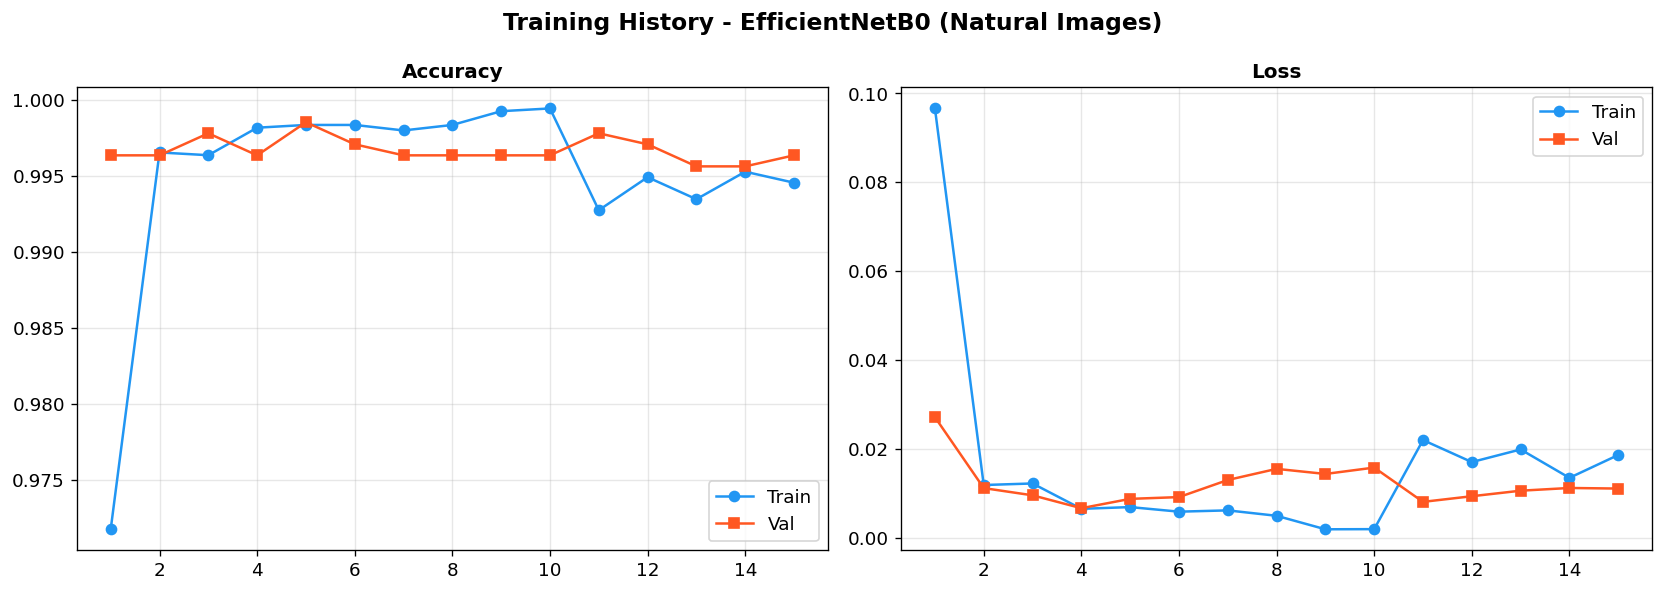

Best val accuracy: 0.9985


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
eps = range(1, len(history.history['accuracy'])+1)

axes[0].plot(eps, history.history['accuracy'],     'o-', color='#2196F3', label='Train')
axes[0].plot(eps, history.history['val_accuracy'], 's-', color='#FF5722', label='Val')
axes[0].set_title('Accuracy')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(eps, history.history['loss'],     'o-', color='#2196F3', label='Train')
axes[1].plot(eps, history.history['val_loss'], 's-', color='#FF5722', label='Val')
axes[1].set_title('Loss')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Training History - EfficientNetB0 (Natural Images)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/04_training_history.png', bbox_inches='tight')
plt.show()
print(f'Best val accuracy: {max(history.history["val_accuracy"]):.4f}')

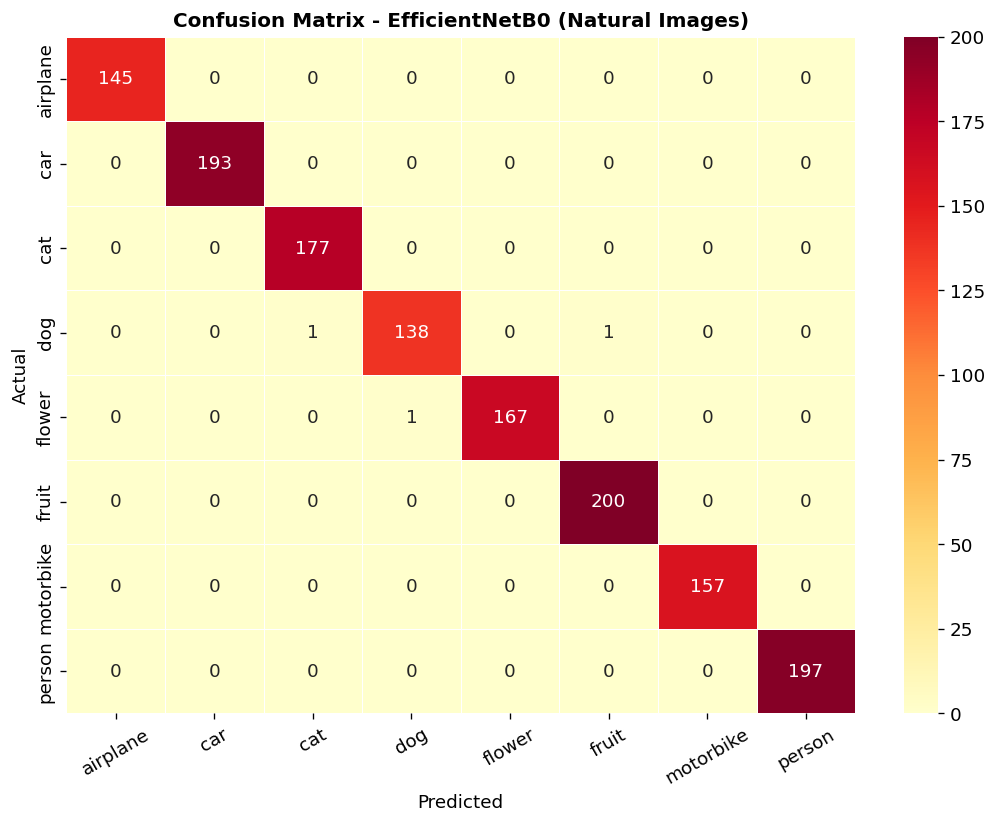

              precision    recall  f1-score   support

    airplane       1.00      1.00      1.00       145
         car       1.00      1.00      1.00       193
         cat       0.99      1.00      1.00       177
         dog       0.99      0.99      0.99       140
      flower       1.00      0.99      1.00       168
       fruit       1.00      1.00      1.00       200
   motorbike       1.00      1.00      1.00       157
      person       1.00      1.00      1.00       197

    accuracy                           1.00      1377
   macro avg       1.00      1.00      1.00      1377
weighted avg       1.00      1.00      1.00      1377



In [10]:
val_gen.reset()
y_pred_prob = model.predict(val_gen, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = val_gen.classes

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=classes, yticklabels=classes,
            linewidths=0.5, ax=ax)
ax.set_title('Confusion Matrix - EfficientNetB0 (Natural Images)')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/05_confusion_matrix.png', bbox_inches='tight')
plt.show()

print(classification_report(y_true, y_pred, target_names=classes))

## 🔍 4. Grad-CAM - Giải thích AI 'nhìn' vào đâu

In [11]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    """Tạo Grad-CAM heatmap từ ảnh đầu vào."""
    # Tách base_model để lấy conv output
    grad_model = tf.keras.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_out = conv_outputs[0]
    heatmap = conv_out @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), int(pred_index), predictions[0].numpy()

# Find last conv layer in base_model
last_conv_layer_name = None
for layer in reversed(model.layers):
    if 'efficientnetb0' in layer.name.lower():
        # Search inside the base_model layer
        for sub_layer in reversed(layer.layers):
            if 'conv' in sub_layer.name.lower():
                last_conv_layer_name = layer.name + '/' + sub_layer.name
                break
        break

# Simpler: build a dedicated grad-cam model
base_layer = model.get_layer('efficientnetb0')
last_conv = None
for layer in reversed(base_layer.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv = layer
        break

print(f'Last conv layer: {last_conv.name}')

Last conv layer: top_conv


In [12]:
# Build dedicated GradCAM model
grad_cam_model = tf.keras.Model(
    inputs=base_layer.input,
    outputs=[last_conv.output, base_layer.output]
)

# Wrapper that uses the full pipeline
def compute_gradcam(img_array):
    with tf.GradientTape() as tape:
        conv_out, features = grad_cam_model(img_array)
        # Pass features through the head
        x = model.get_layer('global_average_pooling2d')(features)
        x = model.get_layer('batch_normalization')(x)
        x = model.get_layer('dense')(x)
        x = model.get_layer('dropout')(x)
        predictions = model.get_layer('dense_1')(x)
        pred_class = tf.argmax(predictions[0])
        class_score = predictions[:, pred_class]

    grads = tape.gradient(class_score, conv_out)
    pooled = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = conv_out[0] @ pooled[..., tf.newaxis]
    heatmap = tf.squeeze(tf.maximum(heatmap, 0))
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), int(pred_class), predictions[0].numpy()

print('Grad-CAM model ready')

Grad-CAM model ready


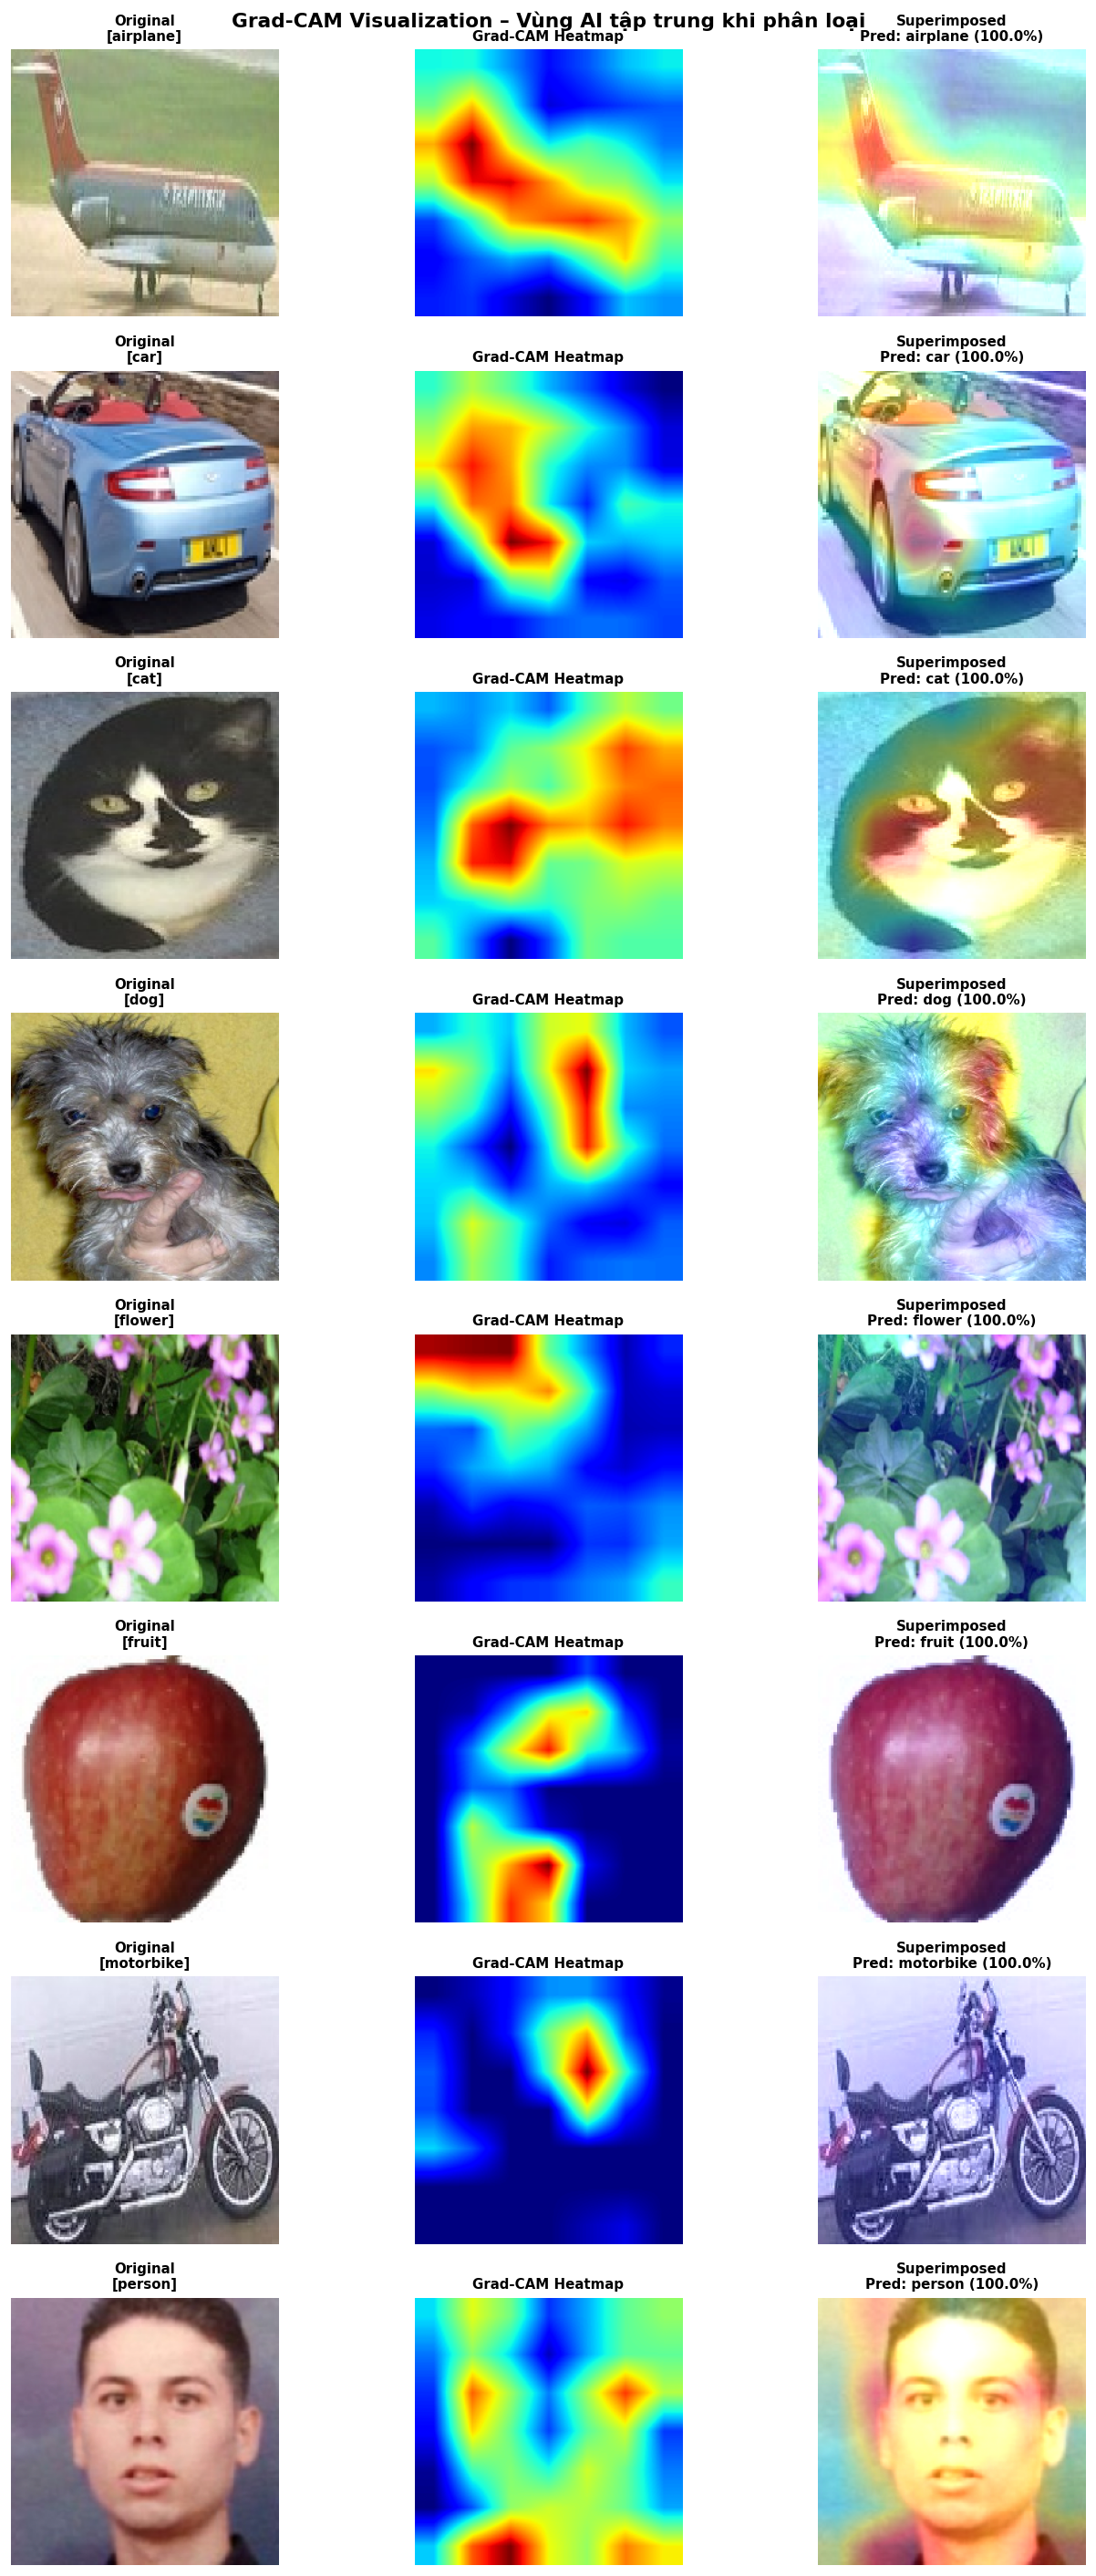

In [13]:
# Show Grad-CAM for one sample per class
fig, axes = plt.subplots(len(classes), 3, figsize=(12, len(classes)*3))

for r, cls in enumerate(classes):
    cls_dir = os.path.join(DATA_DIR, cls)
    sample_file = os.listdir(cls_dir)[0]
    sample_path = os.path.join(cls_dir, sample_file)

    orig_img = load_img(sample_path, target_size=IMG_SIZE)
    img_arr  = img_to_array(orig_img)

    img_display = img_arr / 255.0

    # Preprocess cho model
    img_in = preprocess_input(np.expand_dims(img_arr.copy(), axis=0))

    try:
        heatmap, pred_idx, probs = compute_gradcam(tf.constant(img_in))

        # Resize heatmap
        heatmap_resized = cv2.resize(heatmap, IMG_SIZE)
        heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
        heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB) / 255.0
        superimposed  = heatmap_color * 0.4 + img_display
        superimposed  = np.clip(superimposed, 0, 1)

        pred_label  = classes[pred_idx]
        confidence  = probs[pred_idx] * 100

        axes[r, 0].imshow(orig_img)
        axes[r, 0].set_title(f'Original\n[{cls}]', fontsize=9)
        axes[r, 0].axis('off')

        axes[r, 1].imshow(heatmap_resized, cmap='jet')
        axes[r, 1].set_title('Grad-CAM Heatmap', fontsize=9)
        axes[r, 1].axis('off')

        axes[r, 2].imshow(superimposed)
        axes[r, 2].set_title(f'Superimposed\nPred: {pred_label} ({confidence:.1f}%)', fontsize=9)
        axes[r, 2].axis('off')
    except Exception as e:
        for c in range(3):
            axes[r, c].axis('off')
        axes[r, 0].set_title(f'{cls}\nGradCAM Error: {e}', fontsize=9)

plt.suptitle('Grad-CAM Visualization – Vùng AI tập trung khi phân loại',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/06_gradcam_visualization.png', bbox_inches='tight')
plt.show()


In [14]:
best_val_acc = max(history.history['val_accuracy'])
with open(f'{SAVE_DIR}/report.txt', 'w') as f:
    f.write('Natural Images Classification - EfficientNetB0 + GradCAM\n' + '='*55 + '\n')
    f.write(f'Best Val Accuracy: {best_val_acc:.4f}\n')
    f.write(f'Total Params: {model.count_params():,}\n\n')
    f.write(classification_report(y_true, y_pred, target_names=classes))

print('Natural Images EfficientNet + GradCAM Completed! Results saved to', SAVE_DIR)

Natural Images EfficientNet + GradCAM Completed! Results saved to ../results/natural_images
